# FINAL — Diffusion / DDPM per Emerging Jets

Questo notebook implementa il **Diffusion Model finale** usando i dataset aggregate creati dal preprocessing `FINAL`.

Input previsto:

```text
FINAL/processed/repr1_aggregate.npz
```

Schema dati:

```text
bkg_train  -> training QCD
bkg_eval   -> validation QCD + test QCD interno
sig        -> signal EJ
```

Se nel file è già presente un `bkg_test`, viene usato quello come test QCD.  
Altrimenti `bkg_eval` viene diviso in:

```text
bkg_val  -> early stopping
bkg_test -> ROC/AUC finale contro signal
```

Score di anomalia:

```text
score = denoising error
```

Il modello riceve una versione rumorosa del jet aggregato `x_t` e il timestep `t`, e impara a predire il rumore gaussiano aggiunto.

Questo notebook prende le parti migliori da:
- `tabular_diffusion_emerging_jets_v2.ipynb`: Residual MLP con LayerNorm, score per timestep, z-normalized score;
- `diffusion_model_anomaly.ipynb`: spiegazione DDPM, curva AUC per timestep, evaluation a FPR fissato;
- `05_diffusion_locale.ipynb`: score whitened / normalizzato e confronto tra score diversi.

Non rifà il preprocessing HDF5.

## 1. Import, seed e device

In [1]:
from pathlib import Path
import json
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cpu
CUDA available: False
Using device: cpu


## 2. Path e caricamento dataset aggregate

In [2]:
# Funziona sia se il notebook è lanciato da FINAL/notebooks,
# sia se è lanciato dalla root del progetto.

CANDIDATE_BASES = [
    Path(".."),
    Path("."),
    Path("FINAL"),
]

PROCESSED_PATH = None

for base in CANDIDATE_BASES:
    candidate = base / "processed" / "repr1_aggregate.npz"
    if candidate.exists():
        PROCESSED_PATH = candidate
        PROJECT_BASE = base
        break

if PROCESSED_PATH is None:
    raise FileNotFoundError(
        "Non trovo repr1_aggregate.npz. "
        "Controlla che esista in FINAL/processed/repr1_aggregate.npz "
        "oppure modifica PROCESSED_PATH manualmente."
    )

OUTPUT_DIR = PROJECT_BASE / "outputs" / "diffusion"
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("PROCESSED_PATH:", PROCESSED_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

data = np.load(PROCESSED_PATH, allow_pickle=True)
print("\nKeys in repr1_aggregate.npz:")
for k in data.keys():
    arr = data[k]
    print(f"  {k:35s} shape={arr.shape} dtype={arr.dtype}")

PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
PROCESSED_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr1_aggregate.npz
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\diffusion

Keys in repr1_aggregate.npz:
  bkg_train                           shape=(40000, 96) dtype=float32
  bkg_eval                            shape=(40000, 96) dtype=float32
  sig                                 shape=(40000, 96) dtype=float32
  feature_names                       shape=(96,) dtype=object
  norm_mean                           shape=(1, 96) dtype=float32
  norm_std                            shape=(1, 96) dtype=float32


## 3. Loader robusto delle chiavi

In [3]:
def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError(
            "Nessuna delle chiavi candidate è presente: "
            + ", ".join(candidates)
            + "\nChiavi disponibili: "
            + ", ".join(data.keys())
        )
    return None


train_key = first_existing_key(
    data,
    [
        "X_agg_bkg_train",
        "bkg_train",
        "X_bkg_train",
        "X_train_background",
        "X_agg_train_background",
        "train_background",
        "X_train",
    ],
)

eval_key = first_existing_key(
    data,
    [
        "X_agg_bkg_eval",
        "bkg_eval",
        "X_bkg_eval",
        "X_eval_background",
        "X_agg_eval_background",
        "eval_background",
        "X_eval",
        "X_val",
    ],
)

test_bkg_key = first_existing_key(
    data,
    [
        "X_agg_bkg_test",
        "bkg_test",
        "X_bkg_test",
        "X_test_background",
        "X_agg_test_background",
        "test_background",
        "X_test_bkg",
    ],
    required=False,
)

sig_key = first_existing_key(
    data,
    [
        "X_agg_sig",
        "sig",
        "X_sig",
        "X_signal",
        "X_test_signal",
        "X_agg_test_signal",
        "test_signal",
    ],
)

feature_key = first_existing_key(
    data,
    [
        "aggregate_feature_names",
        "agg_feature_names",
        "feature_names",
        "X_agg_feature_names",
    ],
    required=False,
)

X_train_raw = np.asarray(data[train_key], dtype=np.float32)
X_eval_raw = np.asarray(data[eval_key], dtype=np.float32)
X_sig_raw = np.asarray(data[sig_key], dtype=np.float32)

if test_bkg_key is not None:
    X_bkg_test_raw = np.asarray(data[test_bkg_key], dtype=np.float32)
    X_val_raw = X_eval_raw
    print("Uso test background separato:", test_bkg_key)
else:
    X_val_raw, X_bkg_test_raw = train_test_split(
        X_eval_raw,
        test_size=0.5,
        random_state=SEED,
        shuffle=True,
    )
    print("Nessun test background separato trovato: splitto bkg_eval in val/test 50/50.")

if feature_key is not None:
    aggregate_feature_names = [str(x) for x in data[feature_key].tolist()]
else:
    aggregate_feature_names = [f"f{i}" for i in range(X_train_raw.shape[1])]

print("\nSelected keys:")
print("train:", train_key, X_train_raw.shape)
print("eval:", eval_key, X_eval_raw.shape)
print("val:", X_val_raw.shape)
print("bkg_test:", test_bkg_key, X_bkg_test_raw.shape)
print("signal:", sig_key, X_sig_raw.shape)
print("n features:", len(aggregate_feature_names))

Nessun test background separato trovato: splitto bkg_eval in val/test 50/50.

Selected keys:
train: bkg_train (40000, 96)
eval: bkg_eval (40000, 96)
val: (20000, 96)
bkg_test: None (20000, 96)
signal: sig (40000, 96)
n features: 96


## 4. Anti-leakage check

In [4]:
FORBIDDEN_SUBSTRINGS = [
    "isDisplaced",
    "isTagged",
    "salt_pdisp",
    "displacedPtFraction",
    "flavour_label",
    "truthOriginLabel",
    "truthVertexIndex",
    "VSIVertexIndex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventNumber",
    "mcEventWeight",
    "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing",
    "nPrimaryVertices",
    "isRun3",
]

bad_features = []

for name in aggregate_feature_names:
    for bad in FORBIDDEN_SUBSTRINGS:
        if bad.lower() in name.lower():
            bad_features.append(name)

if bad_features:
    print("ERRORE: trovate feature potenzialmente leaky negli input aggregate:")
    for f in bad_features:
        print("  ", f)
    raise RuntimeError("Leakage check failed. Rimuovi queste feature dal preprocessing.")
else:
    print("Leakage check OK: nessuna feature vietata trovata negli input aggregate.")

Leakage check OK: nessuna feature vietata trovata negli input aggregate.


## 5. Pulizia, robust scaling e clipping

In [5]:
def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    finite = np.isfinite(X)
    if not finite.all():
        print(f"[WARN] {name}: sostituisco NaN/inf con 0. Non-finite:", np.sum(~finite))
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X


X_train_raw = finite_array(X_train_raw, "X_train_raw")
X_val_raw = finite_array(X_val_raw, "X_val_raw")
X_bkg_test_raw = finite_array(X_bkg_test_raw, "X_bkg_test_raw")
X_sig_raw = finite_array(X_sig_raw, "X_sig_raw")


class RobustClipScaler:
    def __init__(self, clip_value=8.0, eps=1e-6):
        self.clip_value = clip_value
        self.eps = eps
        self.center = None
        self.scale = None

    def fit(self, X):
        self.center = np.median(X, axis=0, keepdims=True)
        q25 = np.percentile(X, 25, axis=0, keepdims=True)
        q75 = np.percentile(X, 75, axis=0, keepdims=True)
        self.scale = np.maximum(q75 - q25, self.eps)
        return self

    def transform(self, X):
        Xn = (X - self.center) / self.scale
        Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0)
        Xn = np.clip(Xn, -self.clip_value, self.clip_value)
        return Xn.astype(np.float32)

    def state_dict(self):
        return {
            "clip_value": float(self.clip_value),
            "eps": float(self.eps),
            "center": self.center.reshape(-1).tolist(),
            "scale": self.scale.reshape(-1).tolist(),
        }


CLIP_VALUE = 8.0

scaler = RobustClipScaler(clip_value=CLIP_VALUE)
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_bkg_test = scaler.transform(X_bkg_test_raw)
X_sig = scaler.transform(X_sig_raw)

print("After robust scaling + clipping:")
for name, X in [
    ("train", X_train),
    ("val", X_val),
    ("bkg_test", X_bkg_test),
    ("signal", X_sig),
]:
    print(
        f"{name:10s} shape={X.shape} "
        f"mean={X.mean():.4f} std={X.std():.4f} "
        f"clip_frac={np.mean((X <= -CLIP_VALUE) | (X >= CLIP_VALUE)):.5f}"
    )

input_dim = X_train.shape[1]
print("input_dim:", input_dim)

with open(OUTPUT_DIR / "aggregate_diffusion_scaler.json", "w") as f:
    json.dump(scaler.state_dict(), f, indent=2)

print("Saved scaler:", OUTPUT_DIR / "aggregate_diffusion_scaler.json")

After robust scaling + clipping:
train      shape=(40000, 96) mean=0.0187 std=1.1448 clip_frac=0.00941
val        shape=(20000, 96) mean=0.0183 std=1.1440 clip_frac=0.00942
bkg_test   shape=(20000, 96) mean=0.0156 std=1.1429 clip_frac=0.00940
signal     shape=(40000, 96) mean=-0.0520 std=1.6764 clip_frac=0.02471
input_dim: 96
Saved scaler: ..\outputs\diffusion\aggregate_diffusion_scaler.json


## 6. Dataset e DataLoader

In [6]:
class DiffusionDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


BATCH_SIZE = 1024

train_loader = DataLoader(
    DiffusionDataset(X_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    DiffusionDataset(X_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 40
Val batches: 20


## 7. Diffusion schedule

In [7]:
# Tabular DDPM schedule.
# T=200 è un buon compromesso tra stabilità e costo.

T = 200
BETA_START = 1e-4
BETA_END = 2e-2

betas = torch.linspace(BETA_START, BETA_END, T, dtype=torch.float32, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
snr = alpha_bars / (1.0 - alpha_bars)

print("T:", T)
print("beta_start:", BETA_START)
print("beta_end:", BETA_END)
print("alpha_bar first/last:", alpha_bars[0].item(), alpha_bars[-1].item())
print("SNR first/last:", snr[0].item(), snr[-1].item())


def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    a_bar = alpha_bars[t].unsqueeze(1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise

    return xt, noise

T: 200
beta_start: 0.0001
beta_end: 0.02
alpha_bar first/last: 0.9998999834060669 0.1321827620267868
SNR first/last: 9997.3408203125 0.1523163616657257


## 8. Modello denoiser residual MLP

In [8]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.emb_dim = emb_dim

    def forward(self, t):
        half_dim = self.emb_dim // 2
        device_t = t.device

        freqs = torch.exp(
            -math.log(10000) * torch.arange(0, half_dim, device=device_t).float() / max(half_dim - 1, 1)
        )

        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)

        if self.emb_dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)

        return emb


class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.05):
        super().__init__()

        self.block = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, x):
        return x + self.block(x)


class ResidualTabularDenoiser(nn.Module):
    def __init__(
        self,
        input_dim,
        time_emb_dim=64,
        hidden_dim=384,
        n_blocks=4,
        dropout=0.05,
    ):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_emb_dim)

        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, dropout=dropout)
            for _ in range(n_blocks)
        ])

        self.output = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, xt, t):
        t_h = self.time_mlp(self.time_embedding(t))
        h = self.input_proj(xt) + t_h

        for block in self.blocks:
            h = block(h)

        return self.output(h)

## 9. Training

In [9]:
TIME_EMB_DIM = 64
HIDDEN_DIM = 384
N_BLOCKS = 4
DROPOUT = 0.05

LR = 1e-4
WEIGHT_DECAY = 1e-5

N_EPOCHS = 120
PATIENCE = 18

model = ResidualTabularDenoiser(
    input_dim=input_dim,
    time_emb_dim=TIME_EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    n_blocks=N_BLOCKS,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=6,
)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

ResidualTabularDenoiser(
  (time_embedding): SinusoidalTimeEmbedding()
  (time_mlp): Sequential(
    (0): Linear(in_features=64, out_features=384, bias=True)
    (1): SiLU()
    (2): Linear(in_features=384, out_features=384, bias=True)
  )
  (input_proj): Linear(in_features=96, out_features=384, bias=True)
  (blocks): ModuleList(
    (0-3): 4 x ResidualBlock(
      (block): Sequential(
        (0): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
        (1): SiLU()
        (2): Linear(in_features=384, out_features=384, bias=True)
        (3): Dropout(p=0.05, inplace=False)
        (4): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
        (5): SiLU()
        (6): Linear(in_features=384, out_features=384, bias=True)
      )
    )
  )
  (output): Sequential(
    (0): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): SiLU()
    (2): Linear(in_features=384, out_features=96, bias=True)
  )
)
Parameters: 1436640


In [10]:
def diffusion_loss(model, x0):
    B = x0.shape[0]
    t = torch.randint(0, T, (B,), device=x0.device, dtype=torch.long)
    noise = torch.randn_like(x0)

    xt, noise = q_sample(x0, t, noise=noise)
    pred_noise = model(xt, t)

    return torch.mean((pred_noise - noise) ** 2)


def evaluate_diffusion_loss(model, loader):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            loss = diffusion_loss(model, X_batch)

            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_loss / max(total_items, 1)


train_history = []
val_history = []
lr_history = []

best_val = np.inf
best_epoch = -1
best_state = None
epochs_no_improve = 0

for epoch in range(N_EPOCHS):
    model.train()

    total_loss = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        loss = diffusion_loss(model, X_batch)

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    train_loss = total_loss / max(total_items, 1)
    val_loss = evaluate_diffusion_loss(model, val_loader)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_history.append(train_loss)
    val_history.append(val_loss)
    lr_history.append(current_lr)

    improved = val_loss < best_val

    if improved:
        best_val = val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
        f"train loss={train_loss:.6f} | "
        f"val loss={val_loss:.6f} | "
        f"best={best_val:.6f} @ {best_epoch} | "
        f"lr={current_lr:.2e}"
    )

    if epochs_no_improve >= PATIENCE:
        print("Early stopping.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model from epoch {best_epoch} with val loss={best_val:.6f}")

df_history = pd.DataFrame({
    "epoch": np.arange(1, len(train_history) + 1),
    "train_loss": train_history,
    "val_loss": val_history,
    "lr": lr_history,
})

df_history.to_csv(OUTPUT_DIR / "diffusion_training_history.csv", index=False)
print("Saved:", OUTPUT_DIR / "diffusion_training_history.csv")

Epoch 001/120 | train loss=0.972579 | val loss=0.874633 | best=0.874633 @ 1 | lr=1.00e-04
Epoch 002/120 | train loss=0.821935 | val loss=0.752873 | best=0.752873 @ 2 | lr=1.00e-04
Epoch 003/120 | train loss=0.724609 | val loss=0.674872 | best=0.674872 @ 3 | lr=1.00e-04
Epoch 004/120 | train loss=0.655490 | val loss=0.615312 | best=0.615312 @ 4 | lr=1.00e-04
Epoch 005/120 | train loss=0.607266 | val loss=0.572655 | best=0.572655 @ 5 | lr=1.00e-04
Epoch 006/120 | train loss=0.568973 | val loss=0.545098 | best=0.545098 @ 6 | lr=1.00e-04
Epoch 007/120 | train loss=0.540716 | val loss=0.520294 | best=0.520294 @ 7 | lr=1.00e-04
Epoch 008/120 | train loss=0.522158 | val loss=0.504933 | best=0.504933 @ 8 | lr=1.00e-04
Epoch 009/120 | train loss=0.508345 | val loss=0.489962 | best=0.489962 @ 9 | lr=1.00e-04
Epoch 010/120 | train loss=0.496955 | val loss=0.482451 | best=0.482451 @ 10 | lr=1.00e-04
Epoch 011/120 | train loss=0.488484 | val loss=0.477781 | best=0.477781 @ 11 | lr=1.00e-04
Epoch 01

## 10. Training plots

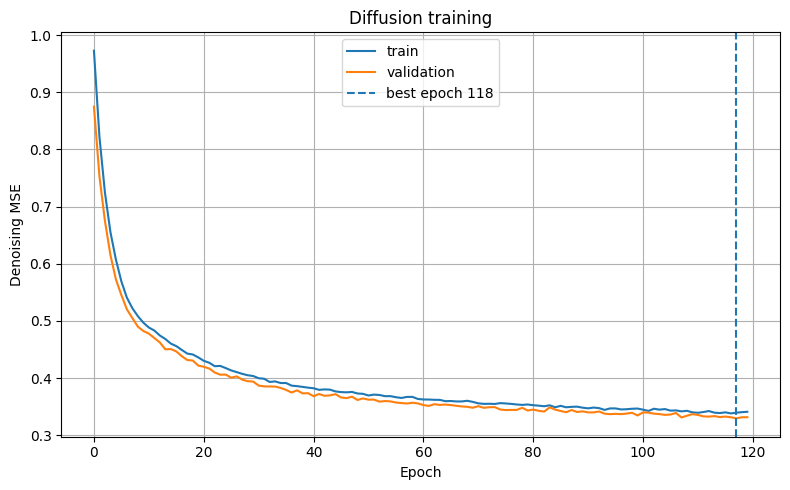

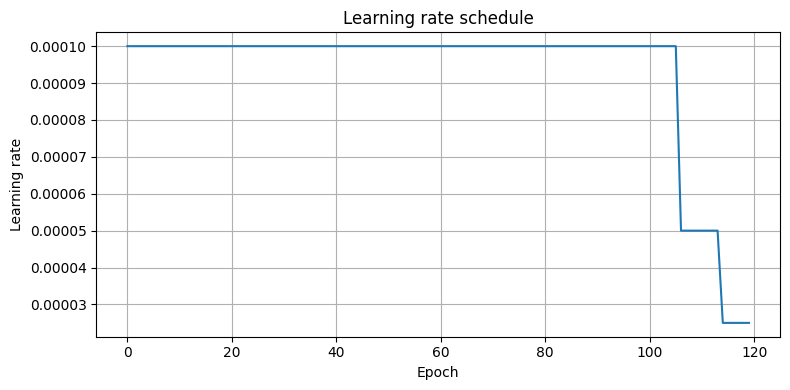

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_history, label="train")
plt.plot(val_history, label="validation")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Denoising MSE")
plt.title("Diffusion training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_training_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_lr_schedule.png", dpi=200)
plt.show()

## 11. Denoising scores per timestep

In [12]:
# Timestep scelti sulla base dei run precedenti:
# low spesso debole, mid e mid+high spesso più informativi.

timesteps_all = torch.tensor([5, 10, 20, 40, 70, 100, 140, 180], dtype=torch.long, device=device)
timesteps_low = torch.tensor([5, 10, 20], dtype=torch.long, device=device)
timesteps_mid = torch.tensor([40, 70, 100], dtype=torch.long, device=device)
timesteps_high = torch.tensor([140, 180], dtype=torch.long, device=device)
timesteps_mid_high = torch.tensor([40, 70, 100, 140, 180], dtype=torch.long, device=device)

print("timesteps_all:", timesteps_all.cpu().numpy())


def compute_per_timestep_scores(model, X, timesteps, batch_size=2048, n_noise_repeats=3):
    loader = DataLoader(
        DiffusionDataset(X),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    all_scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            B = X_batch.shape[0]

            scores_batch = []

            for t_scalar in timesteps:
                t = torch.full((B,), int(t_scalar.item()), device=device, dtype=torch.long)

                score_sum = torch.zeros(B, device=device)

                for _ in range(n_noise_repeats):
                    noise = torch.randn_like(X_batch)
                    xt, true_noise = q_sample(X_batch, t, noise=noise)
                    pred_noise = model(xt, t)

                    mse = torch.mean((pred_noise - true_noise) ** 2, dim=1)
                    score_sum += mse

                score_t = score_sum / n_noise_repeats
                scores_batch.append(score_t.unsqueeze(1))

            scores_batch = torch.cat(scores_batch, dim=1)
            all_scores.append(scores_batch.cpu().numpy())

    return np.concatenate(all_scores, axis=0)


N_NOISE_REPEATS = 3

train_scores_t = compute_per_timestep_scores(model, X_train, timesteps_all, n_noise_repeats=N_NOISE_REPEATS)
val_scores_t = compute_per_timestep_scores(model, X_val, timesteps_all, n_noise_repeats=N_NOISE_REPEATS)
bkg_test_scores_t = compute_per_timestep_scores(model, X_bkg_test, timesteps_all, n_noise_repeats=N_NOISE_REPEATS)
sig_scores_t = compute_per_timestep_scores(model, X_sig, timesteps_all, n_noise_repeats=N_NOISE_REPEATS)

print("train_scores_t:", train_scores_t.shape)
print("val_scores_t:", val_scores_t.shape)
print("bkg_test_scores_t:", bkg_test_scores_t.shape)
print("sig_scores_t:", sig_scores_t.shape)

timesteps_all: [  5  10  20  40  70 100 140 180]
train_scores_t: (40000, 8)
val_scores_t: (20000, 8)
bkg_test_scores_t: (20000, 8)
sig_scores_t: (40000, 8)


## 12. Costruzione score raw e z-normalized

In [13]:
# Indici rispetto a timesteps_all = [5, 10, 20, 40, 70, 100, 140, 180]
IDX_LOW = [0, 1, 2]
IDX_MID = [3, 4, 5]
IDX_HIGH = [6, 7]
IDX_MID_HIGH = [3, 4, 5, 6, 7]


def make_score_dict(scores_t, train_mean=None, train_std=None):
    raw = {
        "raw_all": scores_t.mean(axis=1),
        "raw_low": scores_t[:, IDX_LOW].mean(axis=1),
        "raw_mid": scores_t[:, IDX_MID].mean(axis=1),
        "raw_high": scores_t[:, IDX_HIGH].mean(axis=1),
        "raw_mid_high": scores_t[:, IDX_MID_HIGH].mean(axis=1),
    }

    out = dict(raw)

    if train_mean is not None and train_std is not None:
        z = (scores_t - train_mean) / train_std
        out.update({
            "z_all": z.mean(axis=1),
            "z_low": z[:, IDX_LOW].mean(axis=1),
            "z_mid": z[:, IDX_MID].mean(axis=1),
            "z_high": z[:, IDX_HIGH].mean(axis=1),
            "z_mid_high": z[:, IDX_MID_HIGH].mean(axis=1),
        })

    return out


train_t_mean = train_scores_t.mean(axis=0, keepdims=True)
train_t_std = np.maximum(train_scores_t.std(axis=0, keepdims=True), 1e-8)

scores_train = make_score_dict(train_scores_t, train_t_mean, train_t_std)
scores_val = make_score_dict(val_scores_t, train_t_mean, train_t_std)
scores_bkg_test = make_score_dict(bkg_test_scores_t, train_t_mean, train_t_std)
scores_sig = make_score_dict(sig_scores_t, train_t_mean, train_t_std)

print("Available score variants:")
print(list(scores_train.keys()))


def print_summary(name, scores):
    print("\n", name)
    print("mean:", float(np.mean(scores)))
    print("std:", float(np.std(scores)))
    print("median:", float(np.median(scores)))
    print("quantiles:", np.percentile(scores, [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]))


print_summary("bkg_test z_all", scores_bkg_test["z_all"])
print_summary("signal z_all", scores_sig["z_all"])

Available score variants:
['raw_all', 'raw_low', 'raw_mid', 'raw_high', 'raw_mid_high', 'z_all', 'z_low', 'z_mid', 'z_high', 'z_mid_high']

 bkg_test z_all
mean: 0.019987016916275024
std: 0.6789796948432922
median: -0.06395933777093887
quantiles: [-1.70395887 -1.19057869 -0.88737791 -0.43422434 -0.06395934  0.37144947
  1.19648113  2.09213205  3.58708302 14.56123161]

 signal z_all
mean: 1.3338984251022339
std: 1.546433448791504
median: 1.102983832359314
quantiles: [-1.5815872  -0.59923295 -0.16719955  0.52810809  1.10298383  1.81201884
  3.33776693  5.19940362 18.93173581 21.83768082]


## 13. Metriche e scelta score migliore

In [14]:
def orient_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv


def evaluate_scores(bg, sig, model_name="Diffusion", score_name="score"):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])

    fpr, tpr, thresholds = roc_curve(y, s)

    rows = []
    for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual_mistag = np.mean(bg_o >= threshold)

        rows.append({
            "model": model_name,
            "score": score_name,
            "auc": best_auc,
            "raw_auc": auc,
            "auc_inverted": auc_inv,
            "flipped": flipped,
            "mistag_target": mistag,
            "actual_mistag": actual_mistag,
            "signal_efficiency": eff,
            "threshold": threshold,
        })

    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "best_auc": best_auc,
        "auc": auc,
        "auc_inverted": auc_inv,
        "flipped": flipped,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "eff_table": pd.DataFrame(rows),
    }


evals = {}
rows = []

for score_name in scores_bkg_test.keys():
    ev = evaluate_scores(
        scores_bkg_test[score_name],
        scores_sig[score_name],
        model_name="Diffusion",
        score_name=score_name,
    )
    evals[score_name] = ev

    rows.append({
        "model": "Diffusion",
        "score": score_name,
        "auc": ev["auc"],
        "auc_inverted": ev["auc_inverted"],
        "best_auc": ev["best_auc"],
        "flipped": ev["flipped"],
    })

df_score_comparison = pd.DataFrame(rows).sort_values("best_auc", ascending=False).reset_index(drop=True)
display(df_score_comparison)

best_score_name = df_score_comparison.iloc[0]["score"]
best_eval = evals[best_score_name]

print("Best score:", best_score_name)
print("Best AUC:", best_eval["best_auc"])

display(best_eval["eff_table"])

,model,score,auc,auc_inverted,best_auc,flipped
0,Diffusion,z_all,0.859812,0.140188,0.859812,False
1,Diffusion,raw_all,0.859403,0.140597,0.859403,False
2,Diffusion,raw_mid_high,0.845082,0.154918,0.845082,False
3,Diffusion,z_mid_high,0.844266,0.155734,0.844266,False
4,Diffusion,raw_mid,0.836730,0.163270,0.836730,False
5,Diffusion,z_mid,0.836311,0.163689,0.836311,False
6,Diffusion,z_high,0.813008,0.186992,0.813008,False
7,Diffusion,raw_high,0.812825,0.187175,0.812825,False
8,Diffusion,z_low,0.811190,0.188810,0.811190,False
9,Diffusion,raw_low,0.810095,0.189905,0.810095,False


Best score: z_all
Best AUC: 0.8598121475


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,Diffusion,z_all,0.859812,0.859812,0.140188,False,0.300,0.300,0.844800,0.272313
1,Diffusion,z_all,0.859812,0.859812,0.140188,False,0.100,0.100,0.615875,0.833718
2,Diffusion,z_all,0.859812,0.859812,0.140188,False,0.050,0.050,0.459750,1.196481
3,Diffusion,z_all,0.859812,0.859812,0.140188,False,0.010,0.010,0.187650,2.092132
4,Diffusion,z_all,0.859812,0.859812,0.140188,False,0.001,0.001,0.038050,3.587083


## 14. Background checks

In [15]:
def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([np.zeros_like(a), np.ones_like(b)])
    s = np.concatenate([a, b])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    return {
        "comparison": f"{name_a} vs {name_b}",
        "auc": auc,
        "auc_inverted": auc_inv,
        "best_auc": max(auc, auc_inv),
    }


bg_checks = pd.DataFrame([
    bg_vs_bg_auc(scores_train[best_score_name], scores_val[best_score_name], "train QCD", "val QCD"),
    bg_vs_bg_auc(scores_train[best_score_name], scores_bkg_test[best_score_name], "train QCD", "test QCD"),
    bg_vs_bg_auc(scores_val[best_score_name], scores_bkg_test[best_score_name], "val QCD", "test QCD"),
])

display(bg_checks)

,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.508064,0.491936,0.508064
1,train QCD vs test QCD,0.508558,0.491442,0.508558
2,val QCD vs test QCD,0.500465,0.499535,0.500465


## 15. Plot ROC, score distribution, efficiency vs mistag

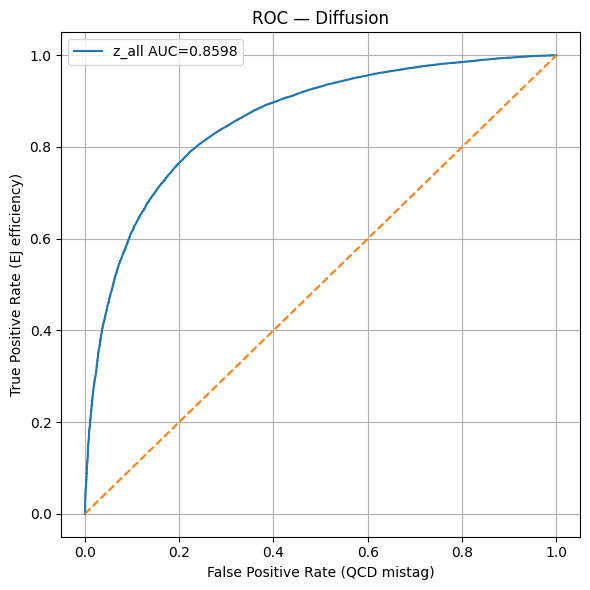

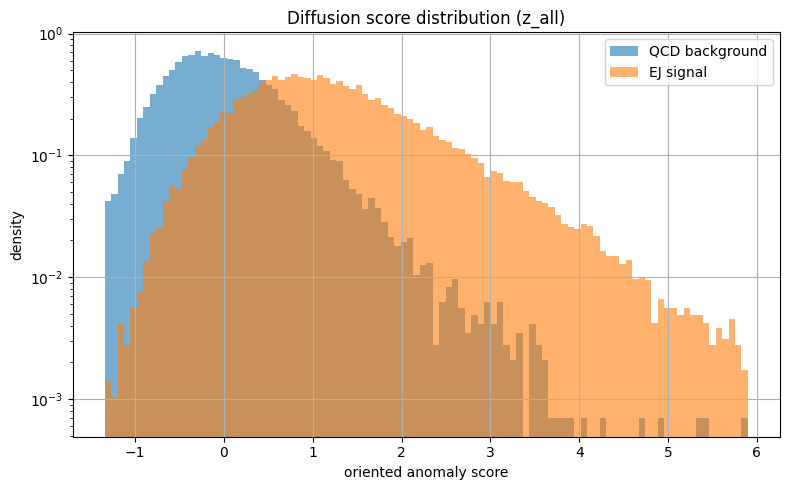

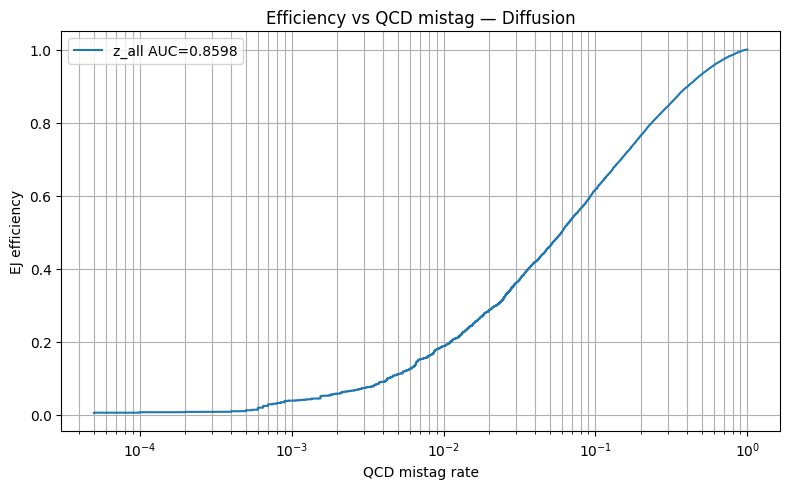

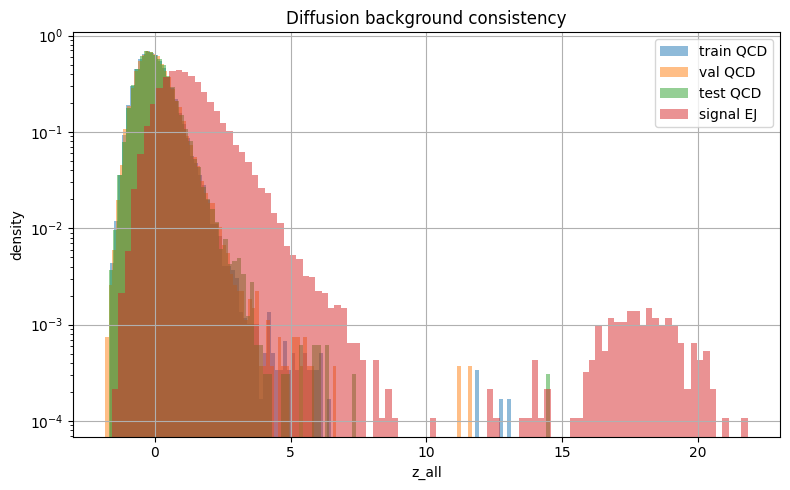

In [16]:
bg_o = best_eval["bg_oriented"]
sig_o = best_eval["sig_oriented"]

plt.figure(figsize=(6, 6))
plt.plot(best_eval["fpr"], best_eval["tpr"], label=f"{best_score_name} AUC={best_eval['best_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (QCD mistag)")
plt.ylabel("True Positive Rate (EJ efficiency)")
plt.title("ROC — Diffusion")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_roc.png", dpi=200)
plt.show()

all_scores = np.concatenate([bg_o, sig_o])
lo = np.percentile(all_scores, 0.1)
hi = np.percentile(all_scores, 99.5)

plt.figure(figsize=(8, 5))
plt.hist(bg_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
plt.hist(sig_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ signal")
plt.yscale("log")
plt.xlabel("oriented anomaly score")
plt.ylabel("density")
plt.title(f"Diffusion score distribution ({best_score_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_score_distribution.png", dpi=200)
plt.show()

fpr = best_eval["fpr"]
tpr = best_eval["tpr"]
mask = fpr > 0

plt.figure(figsize=(8, 5))
plt.plot(fpr[mask], tpr[mask], label=f"{best_score_name} AUC={best_eval['best_auc']:.4f}")
plt.xscale("log")
plt.xlabel("QCD mistag rate")
plt.ylabel("EJ efficiency")
plt.title("Efficiency vs QCD mistag — Diffusion")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_efficiency_vs_mistag.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(scores_train[best_score_name], bins=100, density=True, alpha=0.5, label="train QCD")
plt.hist(scores_val[best_score_name], bins=100, density=True, alpha=0.5, label="val QCD")
plt.hist(scores_bkg_test[best_score_name], bins=100, density=True, alpha=0.5, label="test QCD")
plt.hist(scores_sig[best_score_name], bins=100, density=True, alpha=0.5, label="signal EJ")
plt.yscale("log")
plt.xlabel(best_score_name)
plt.ylabel("density")
plt.title("Diffusion background consistency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_background_consistency.png", dpi=200)
plt.show()

## 16. AUC per timestep

,timestep,auc,auc_inverted,best_auc,flipped
0,5,0.661405,0.338595,0.661405,False
1,10,0.745349,0.254651,0.745349,False
2,20,0.781201,0.218799,0.781201,False
3,40,0.796825,0.203175,0.796825,False
4,70,0.798378,0.201622,0.798378,False
5,100,0.793403,0.206597,0.793403,False
6,140,0.792516,0.207484,0.792516,False
7,180,0.790516,0.209484,0.790516,False


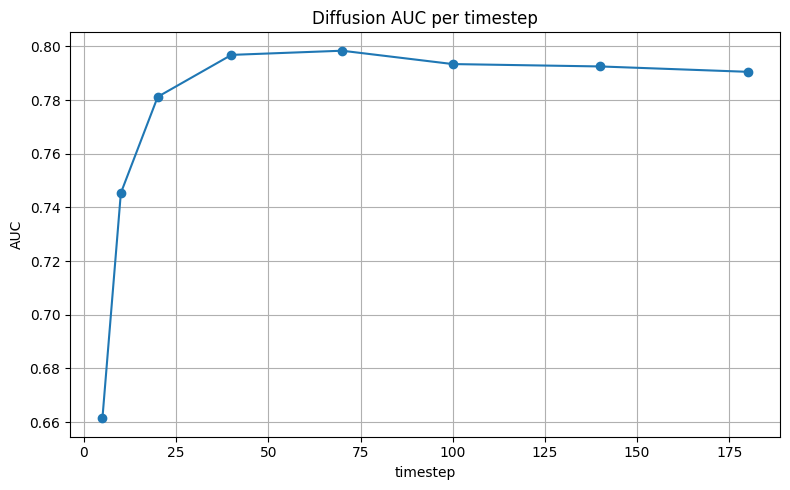

In [17]:
per_timestep_rows = []

for i, t in enumerate(timesteps_all.cpu().numpy().tolist()):
    ev_t = evaluate_scores(
        bkg_test_scores_t[:, i],
        sig_scores_t[:, i],
        model_name="Diffusion",
        score_name=f"t={t}",
    )
    per_timestep_rows.append({
        "timestep": t,
        "auc": ev_t["auc"],
        "auc_inverted": ev_t["auc_inverted"],
        "best_auc": ev_t["best_auc"],
        "flipped": ev_t["flipped"],
    })

df_per_timestep = pd.DataFrame(per_timestep_rows)
display(df_per_timestep)

plt.figure(figsize=(8, 5))
plt.plot(df_per_timestep["timestep"], df_per_timestep["best_auc"], marker="o")
plt.xlabel("timestep")
plt.ylabel("AUC")
plt.title("Diffusion AUC per timestep")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_auc_per_timestep.png", dpi=200)
plt.show()

## 17. Sampling sanity check opzionale

sampled shape: (3000, 96)
sampled finite: True
sampled mean/std: 0.033354986 0.74787253
sampled quantiles: [-1.17026320e+01 -1.85011011e+00 -1.06887836e+00 -3.43981735e-01
  2.02288234e-03  3.97179894e-01  1.23295067e+00  2.10783176e+00
  1.02076607e+01]


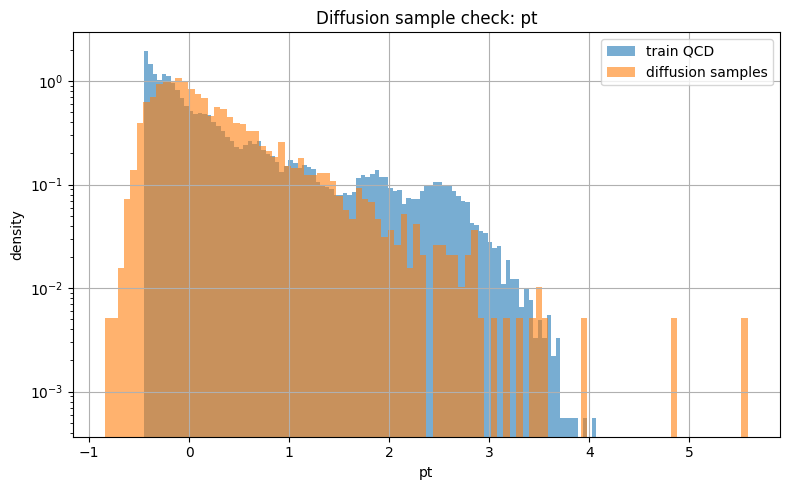

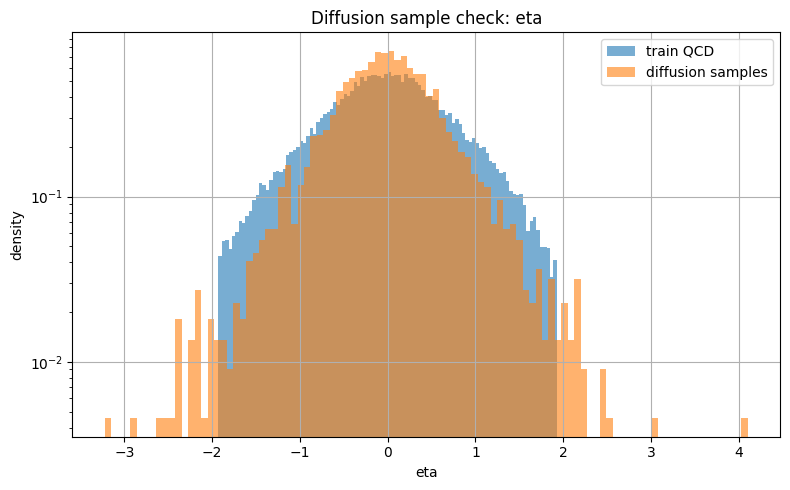

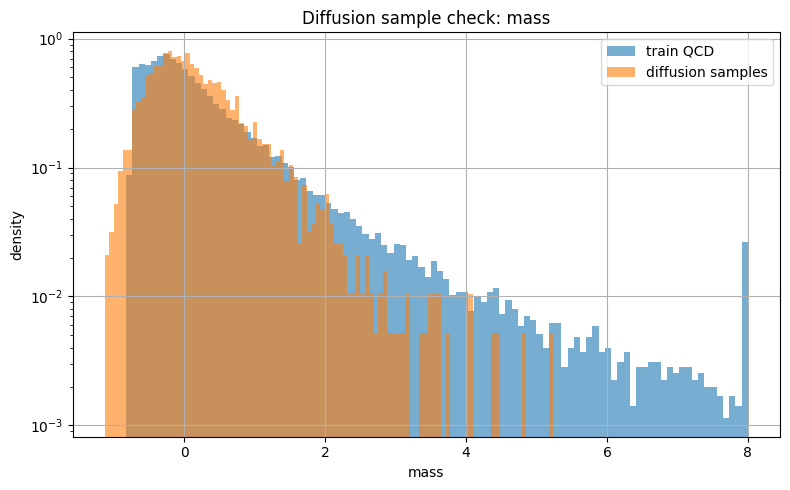

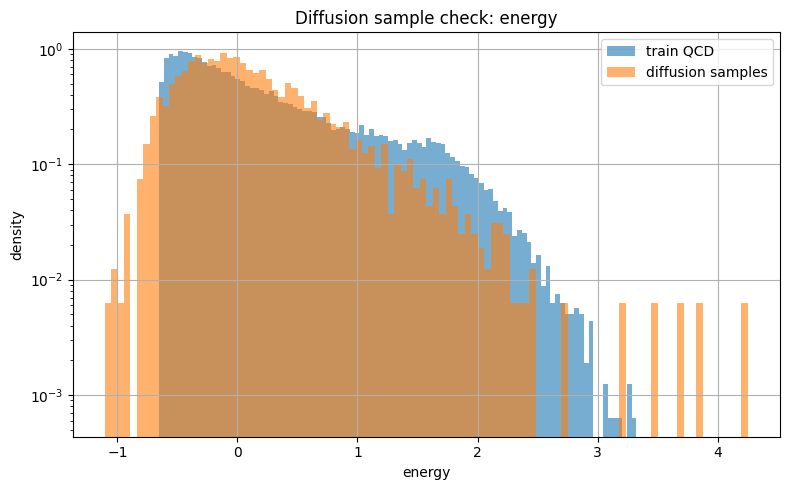

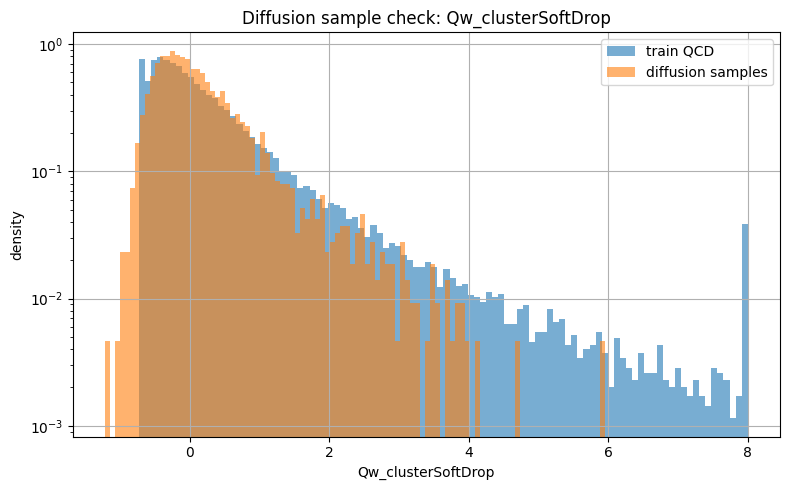

In [18]:
# Sampling DDPM inverso semplificato.
# Non è il risultato principale, serve solo come sanity check generativo.

@torch.no_grad()
def sample_diffusion(model, n_samples, input_dim):
    model.eval()

    x = torch.randn(n_samples, input_dim, device=device)

    for t_int in reversed(range(T)):
        t = torch.full((n_samples,), t_int, device=device, dtype=torch.long)

        beta_t = betas[t].unsqueeze(1)
        alpha_t = alphas[t].unsqueeze(1)
        alpha_bar_t = alpha_bars[t].unsqueeze(1)

        eps_pred = model(x, t)

        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred
        )

        if t_int > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * noise
        else:
            x = mean

    return x.cpu().numpy()


N_SAMPLES = 3000
x_sampled = sample_diffusion(model, n_samples=N_SAMPLES, input_dim=input_dim)

print("sampled shape:", x_sampled.shape)
print("sampled finite:", np.isfinite(x_sampled).all())
print("sampled mean/std:", x_sampled.mean(), x_sampled.std())
print("sampled quantiles:", np.percentile(x_sampled.ravel(), [0, 1, 5, 25, 50, 75, 95, 99, 100]))

for i in range(min(5, input_dim)):
    plt.figure(figsize=(8, 5))
    plt.hist(X_train[:, i], bins=100, density=True, alpha=0.6, label="train QCD")
    plt.hist(x_sampled[:, i], bins=100, density=True, alpha=0.6, label="diffusion samples")
    plt.yscale("log")
    plt.xlabel(aggregate_feature_names[i])
    plt.ylabel("density")
    plt.title(f"Diffusion sample check: {aggregate_feature_names[i]}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"diffusion_sample_check_feature_{i}.png", dpi=200)
    plt.show()

## 18. Salvataggio finale

In [19]:
results_summary = {
    "model": "Diffusion",
    "best_score": str(best_score_name),
    "auc": float(best_eval["auc"]),
    "auc_inverted": float(best_eval["auc_inverted"]),
    "best_auc": float(best_eval["best_auc"]),
    "flipped": bool(best_eval["flipped"]),
    "input_dim": int(input_dim),
    "T": int(T),
    "beta_start": float(BETA_START),
    "beta_end": float(BETA_END),
    "time_emb_dim": int(TIME_EMB_DIM),
    "hidden_dim": int(HIDDEN_DIM),
    "n_blocks": int(N_BLOCKS),
    "dropout": float(DROPOUT),
    "learning_rate": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val),
    "clip_value": float(CLIP_VALUE),
    "n_noise_repeats": int(N_NOISE_REPEATS),
}

for _, row in bg_checks.iterrows():
    key = row["comparison"].replace(" ", "_").replace("vs", "VS")
    results_summary[f"{key}_best_auc"] = float(row["best_auc"])

with open(OUTPUT_DIR / "diffusion_config.json", "w") as f:
    json.dump(
        {
            **results_summary,
            "aggregate_feature_names": aggregate_feature_names,
            "processed_path": str(PROCESSED_PATH),
            "scaler": scaler.state_dict(),
            "timesteps_all": timesteps_all.cpu().numpy().tolist(),
            "train_t_mean": train_t_mean.reshape(-1).tolist(),
            "train_t_std": train_t_std.reshape(-1).tolist(),
        },
        f,
        indent=2,
    )

best_eval["eff_table"].to_csv(OUTPUT_DIR / "diffusion_results.csv", index=False)
df_score_comparison.to_csv(OUTPUT_DIR / "diffusion_score_comparison.csv", index=False)
df_per_timestep.to_csv(OUTPUT_DIR / "diffusion_auc_per_timestep.csv", index=False)
bg_checks.to_csv(OUTPUT_DIR / "diffusion_background_checks.csv", index=False)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": results_summary,
        "aggregate_feature_names": aggregate_feature_names,
        "scaler": scaler.state_dict(),
        "train_history": train_history,
        "val_history": val_history,
    },
    OUTPUT_DIR / "diffusion_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "diffusion_scores.npz",
    train_scores_t=train_scores_t,
    val_scores_t=val_scores_t,
    bkg_test_scores_t=bkg_test_scores_t,
    sig_scores_t=sig_scores_t,
    timesteps_all=timesteps_all.cpu().numpy(),
    train_t_mean=train_t_mean,
    train_t_std=train_t_std,
    scores_train_raw_all=scores_train["raw_all"],
    scores_val_raw_all=scores_val["raw_all"],
    scores_bkg_test_raw_all=scores_bkg_test["raw_all"],
    scores_sig_raw_all=scores_sig["raw_all"],
    scores_train_z_all=scores_train["z_all"],
    scores_val_z_all=scores_val["z_all"],
    scores_bkg_test_z_all=scores_bkg_test["z_all"],
    scores_sig_z_all=scores_sig["z_all"],
    scores_train_z_mid=scores_train["z_mid"],
    scores_val_z_mid=scores_val["z_mid"],
    scores_bkg_test_z_mid=scores_bkg_test["z_mid"],
    scores_sig_z_mid=scores_sig["z_mid"],
    scores_train_z_mid_high=scores_train["z_mid_high"],
    scores_val_z_mid_high=scores_val["z_mid_high"],
    scores_bkg_test_z_mid_high=scores_bkg_test["z_mid_high"],
    scores_sig_z_mid_high=scores_sig["z_mid_high"],
    best_score_name=np.array(best_score_name, dtype=object),
    best_bg_oriented=best_eval["bg_oriented"],
    best_sig_oriented=best_eval["sig_oriented"],
    fpr=best_eval["fpr"],
    tpr=best_eval["tpr"],
    thresholds=best_eval["thresholds"],
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
    auc=np.array(best_eval["auc"], dtype=np.float32),
    auc_inverted=np.array(best_eval["auc_inverted"], dtype=np.float32),
    best_auc=np.array(best_eval["best_auc"], dtype=np.float32),
)

print("Saved:")
print(OUTPUT_DIR / "diffusion_model.pt")
print(OUTPUT_DIR / "diffusion_scores.npz")
print(OUTPUT_DIR / "diffusion_results.csv")
print(OUTPUT_DIR / "diffusion_score_comparison.csv")
print(OUTPUT_DIR / "diffusion_auc_per_timestep.csv")
print(OUTPUT_DIR / "diffusion_background_checks.csv")
print(OUTPUT_DIR / "diffusion_config.json")
print("plots:", PLOTS_DIR)

Saved:
..\outputs\diffusion\diffusion_model.pt
..\outputs\diffusion\diffusion_scores.npz
..\outputs\diffusion\diffusion_results.csv
..\outputs\diffusion\diffusion_score_comparison.csv
..\outputs\diffusion\diffusion_auc_per_timestep.csv
..\outputs\diffusion\diffusion_background_checks.csv
..\outputs\diffusion\diffusion_config.json
plots: ..\outputs\diffusion\plots
